<a href="https://colab.research.google.com/github/cmaceira-itba/edyp-poo-python/blob/main/Programacion_Orientada_a_Objetos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Índice

1. [¿Qué es un Paradigma de Programación?](#paradigma)
2. [El Paradigma Estructurado](#estructurado)
3. [Problemas del Diseño: Acoplamiento y Cohesión](#acoplamiento-cohesion)
4. [Código Limpio y SOLID](#solid)
5. [El Paradigma Orientado a Objetos](#poo)
6. [Los Cuatro Pilares del Modelo de Objetos](#pilares)
7. [Clases y Objetos en Python](#clases-objetos)
8. [Atributos y Métodos](#atributos-metodos)
9. [Métodos Especiales (Dunder)](#dunder)
10. [Herencia y Composición](#herencia)
11. [Excepciones](#excepciones)
12. [Testing de Clases](#testing)
13. [Fuentes](#fuentes)

# ¿Qué es un paradigma de programación?
Un paradigma de programación es una manera o estilo de programación de software. Existen diferentes formas de diseñar un lenguaje de programación y varios modos de trabajar para obtener los resultados que necesitan los programadores.  Se trata de un conjunto de métodos sistemáticos aplicables en todos los niveles del diseño de programas para resolver problemas computacionales.

Los lenguajes de programación adoptan uno o varios paradigmas en función del tipo de órdenes que permiten implementar como, por ejemplo, Python que es multiparadigma.

En Informatica General aprendimos a utilizar uno de los paradigmas más antiguos, el Paradigma Estructurado. Si no has cursado Informatica General no te preocupes, puedes igualmente apredender a programar utilizando otros paradigmas como el que vamos a aprender en esta materia (Paradigma Orientado a Objetos)

# El Paradigma Estructurado
La programación estructurada es un paradigma de programación orientado a mejorar la claridad, calidad y tiempo de desarrollo de un programa de computadora recurriendo únicamente a funciones y a tres estructuras de control básicas: secuencia, selección (if y switch) e iteración (bucles for y while); asimismo, se considera innecesario y contraproducente el uso de la transferencia incondicional (break y continue); esta instrucción suele acabar generando el llamado código espagueti, mucho más difícil de seguir y de mantener, además de originar numerosos errores de programación.

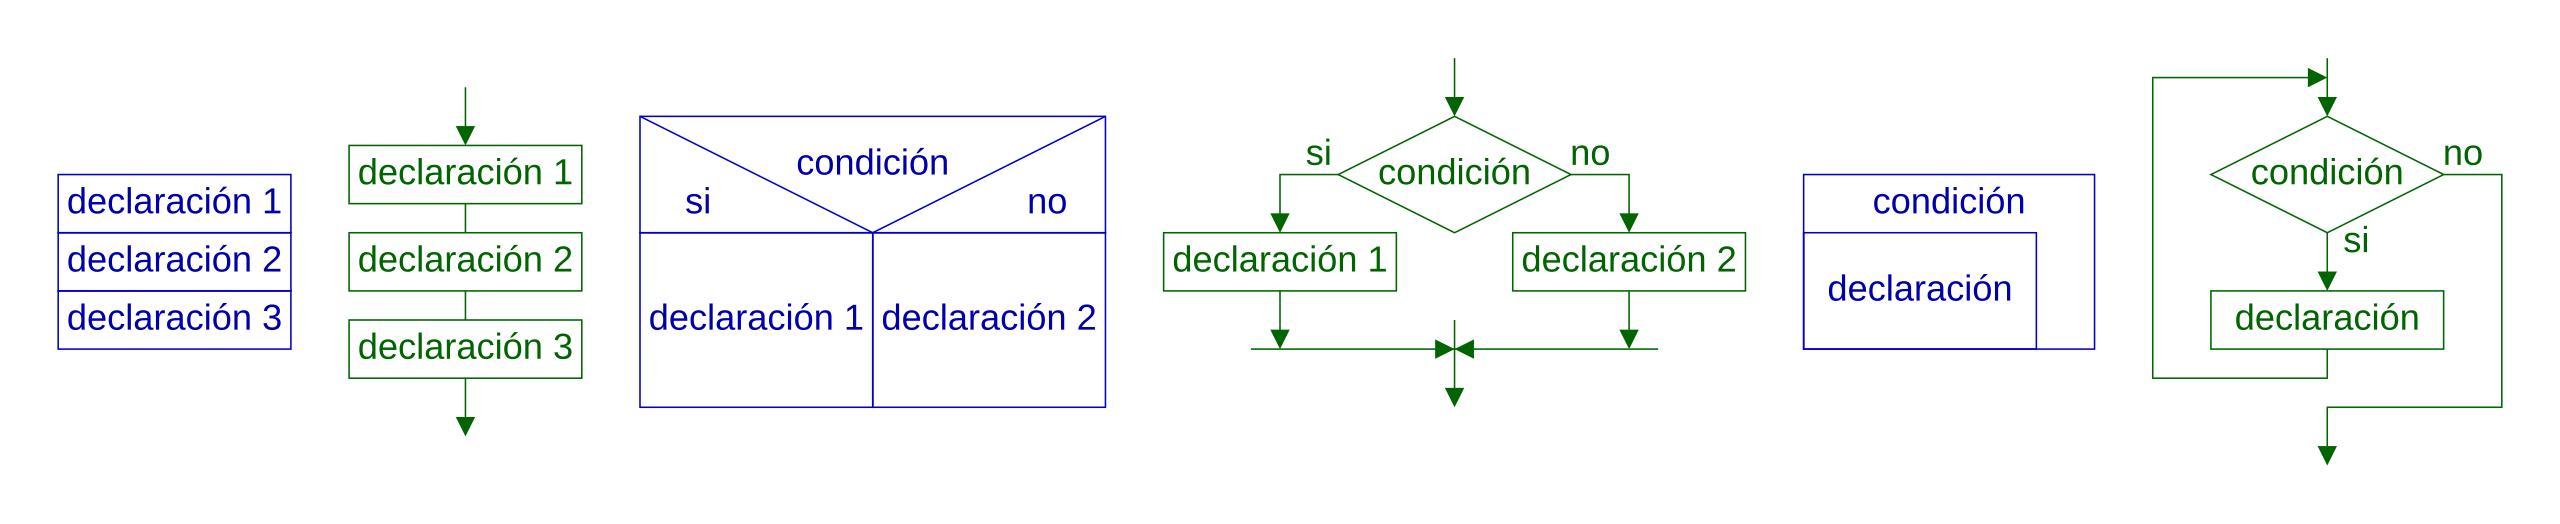

En la programacion estructurada los bloques fundamentales de construccion de los programas son algoritmos que definimos en funciones.

In [ ]:
def factorial(n):
    if n < 0:
        return "El factorial no está definido para números negativos."
    elif n == 0:
        return 1
    else:
        result = 1
        for i in range(1, n + 1):
            result *= i
        return result

# Ejemplo de uso:
numero = 5
print(f"El factorial de {numero} es: {factorial(numero)}")

numero = 0
print(f"El factorial de {numero} es: {factorial(numero)}")

numero = -3
print(f"El factorial de {numero} es: {factorial(numero)}")

El factorial de 5 es: 120
El factorial de 0 es: 1
El factorial de -3 es: El factorial no está definido para números negativos.


## Codigo Espagueti
Es un término peyorativo para los programas de computación que tienen una estructura de control de flujo compleja e incomprensible. Su nombre deriva del hecho que este tipo de código parece asemejarse a un plato de espaguetis, es decir, un montón de hilos intrincados y anudados.

# Acoplamiento
El acoplamiento es el grado en que las clases de un programa dependen unas de otras. Si para hacer cambios en una clase del programa es necesario hacer cambios en otro clase distinta, existe acoplamiento entre ambas clases.

En Programación Orientada a Objetos, si una clase X usa una clase Y, se dice que X depende de Y. Esto es, X no puede realizar su trabajo sin Y, por lo tanto, existe acoplamiento entre las clases X e Y.

Como se observa, el acoplamiento es direccional, puede haber acoplamiento de la clase X con la clase Y, pero esto no implica que exista en sentido inverso.



In [ ]:
class FileManager:
    def __init__(self):
        self.file_path = "./order_log.txt"
        print(f"FileManager: Usando el archivo: {self.file_path}")

    def save_data(self, data):
        with open(self.file_path, 'a') as f:
            f.write(f"{data}\n")
        print(f"FileManager: Datos guardados: {data}")
        return True

class OrderProcessor:
    def __init__(self):
        # Alto acoplamiento: OrderProcessor crea directamente FileManager
        self.file_manager = FileManager()

    def process_order(self, order_details):
        print(f"OrderProcessor: Procesando pedido: {order_details}")
        if self.file_manager.save_data(f"Pedido: {order_details}"):
            print("OrderProcessor: Pedido procesado y registrado exitosamente.")
            return True
        return False

# Ejemplo de uso
processor = OrderProcessor()
processor.process_order("Libro de Python, Cuaderno")

# Problema de acoplamiento: Si se cambia cómo se inicializa FileManager (ej. otro nombre de archivo o formato),
# OrderProcessor debe ser modificado.

# Cohesion
Cohesión es lo contrario a dependencia. Tal como dice el significado de la palabra en castellano, es el efecto de reunirse o adherise las cosas entre sí o la materia de la que está formada. Algo está cohesionado si tiene sentido, y una dirección común.

En ingenieria del software, algo tiene alta cohesión si tiene un alcance definido, unos límites claros y un contenido delimitado y perfectamente ubicado.

En programacion orientada a objetos, una clase tendrá alta cohesión si sus métodos están relacionados entre sí, tienen un contenido claro y temática común, trabajan con tipos similares, etc. Todo bien encerrado dentro de la clase, y perfectamente delimitado.

Por ejemplo, si en nuestro programa tenemos la lógica de escritura de archivos encerrada en una sola clase, o en un paquete de clases, y no que cada clase por separado se gestione su propia logica de guardado de archivos, tendríamos alta cohesión.

En resumen, un código altamente cohesionado tiende a ser mas autocontenido y con menos dependencias.

# Codigo Limpio
## El codigo limpio es obvio para otros programadores
Los nombres de variables pobremente elegidos, clases y métodos extensos y números magicos hacen del codigo desprolijo y dificil de comprender.

## El codigo limpio no tiene lineas duplicadas
Cada vez que haces un cambio en codigo duplicado tenes que repetirlo en cada copia. Esto induce a errores y dificulta la mantenibilidad.

## El codigo limpio tiene la menor cantidad de clases
Menos es codigo facilita el mantenimiento y reduce la cantidad de bugs. El diseño debe ser el minimo para el proposito.

## El codigo limpio pasa todos los tests.
Hay que probar nuestro codigo y asegurarse que cada entrega satisface todos los tests.


# Principios SOLID

## S - Single Responsibility Principle (Principio de Responsabilidad Única)
Una clase debe tener una, y solo una, razón para cambiar.
Si tienes una clase Usuario que gestiona datos del usuario, guarda en base de datos y además envía emails de bienvenida, está haciendo demasiado.
Separa responsabilidades. Usuario (datos), UsuarioRepository (base de datos), EmailService (envíos).

## O - Open/Closed Principle (Principio de Abierto/Cerrado)
Las clases deben estar abiertas para su extensión, pero cerradas para su modificación.
Si quieres agregar una nueva funcionalidad (ej. un nuevo tipo de descuento), no deberías tener que entrar a modificar el código que ya funciona (y arriesgarte a romperlo).
Si tienes que establecer distintas logicas de descuento, utiliza polimorfismo: añade nuevas clases (DescuentoVerano, DescuentoBlackFriday) en lugar de añadir if/else infinitos en una clase Descuento genérica.

## L - Liskov Substitution Principle (Principio de Sustitución de Liskov)
Las clases derivadas (hijas) deben poder sustituirse por sus clases base (padres) sin alterar el comportamiento correcto del programa.
Si tienes una clase Pato y una hija PatoDeHule, y el programa explota porque PatoDeHule no puede volar, estás violando este principio.
Asegúrate de que la herencia tenga sentido semántico y funcional. Si una clase hija no puede cumplir con todo lo que promete el padre, tal vez no debería heredar de ahí (o la abstracción del padre es incorrecta).

## I - Interface Segregation Principle (Principio de Segregación de Interfaz)
"Ninguna clase debería verse forzada a depender de métodos que no utiliza."
Aunque Python no tiene "interfaces" explícitas, este principio es vital cuando diseñamos Clases Base Abstractas (ABCs) o definimos Protocolos. El objetivo es evitar crear una clase base gigante que obligue a sus clases hijas a heredar o implementar métodos que no tienen sentido para ellas.
En Python, si violas este principio, terminas con clases llenas de métodos que no hacen nada (pass) o que lanzan NotImplementedError solo para cumplir con la estructura de la clase padre.
En lugar de una interfaz Trabajador con métodos programar(), diseñar() y vender(), crea interfaces separadas: Programador, Diseñador, Vendedor. Así, quien implemente Programador no estará obligado a implementar vender().

## D - Dependency Inversion Principle (Principio de Inversión de Dependencias)
Los módulos de alto nivel no deben depender de módulos de bajo nivel. Ambos deben depender de abstracciones.
Tu lógica de negocio (alto nivel) no debe conocer los detalles de tu base de datos o API externa (bajo nivel).
No instancies clases concretas dentro de tu lógica (ej. new MySQLDatabase()). En su lugar, inyecta interfaces (ej. IDatabase). Esto permite cambiar de MySQL a MongoDB sin tocar una sola línea de la lógica de negocio.

# ¿Qué es lo ideal?
Teniendo en cuenta todo lo expuesto, hay que buscar las ventajas de cada uno y encontrar el balance que garantiza mayor simplicidad y coherencia. A modo gráfico, la tendencia que deberíamos buscar sería movernos siempre hacia el cuadrante inferior de la derecha, buscando bajo acoplamiento y alta cohesión.
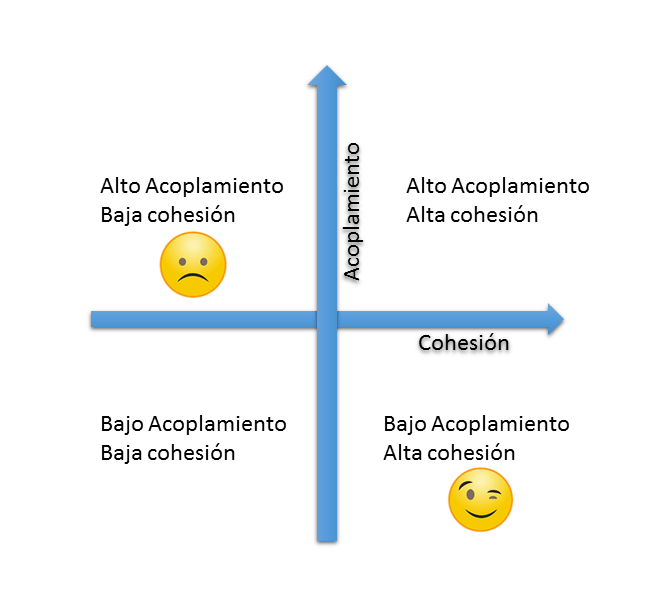

Un bajo acoplamiento nos garantiza:

- Mejorar la mantenibilidad de los módulos del software, facilitar los cambios en el software sin tener que revisar todos los módulos dependientes.
- Mejorar la reutilización de las unidades del software.
- Facilitar las pruebas de cada módulo, al ser más independientes.

Por otro lado, una alta cohesión nos permite:
- Tener un código mas entendebile, legible y coherente.
- Mejorar la reutilización, al tener todo lo relacionado con una cosa, en esa cosa, y no disperso entre módulos.
- Mejorar el mantenimiento del software, ya que todo está perfectamente localizado y los cambios en un módulo no afectarán a módulos externos.
- Facilita las pruebas de caja negra, ya que toda la funcionalidad relacionada con una cosa, está encerrada en esa cosa.

# El Paradigma Orientado a Objetos
## Programacion Orientada a Objetos
Es una forma de programacion en la cual los programas son organizados como una coleccion de *objetos* que cooperan, cada uno de los cuales es una instancia de alguna Clase, las cuales son miembros de una jerarquia de Clases relacionadas.

## Analisis Orientado a Objetos
El análisis orientado a objetos es un método de análisis que examina los requisitos desde la perspectiva de las clases y los objetos que se encuentran en el vocabulario del dominio del problema.
Consiste en analizar los requisitos del sistema observando al problema en termino de objetos.
- Estos objetos represantan entidades fisicas o abstractas del mundo real o conceptos que son relevantes.
- El objetivo consite en identificar los objetos, sus atributos, comportamientos y relaciones, sin enfocarse en como serán implementados.

Por ejemplo: Supongamos que estás desarrollando un juego:

El AOO te ayuda a comprender todo lo que necesitas saber sobre el mundo del juego: los personajes, sus características y cómo interactúan.
Es como crear un mapa de todo lo importante.
El AOO también te ayuda a comprender qué harán los personajes de tu juego. Es como escribir un guion para cada personaje.
Cada programa tiene tareas o trabajos específicos que debe realizar. El AOO te ayuda a enumerar y describir estos trabajos.
En nuestro juego, podrían ser tareas como mover personajes o llevar la puntuación. Es como crear una lista de tareas para tu software.
El AOO es inteligente al dividir las cosas en diferentes partes. Divide el trabajo en tres categorías: cosas que tu juego sabe, cosas que tu juego hace y cómo se comportan los elementos en tu juego.

## Diseño Orientado a Objetos
El diseño orientado a objetos es un método de diseño de software que abarca el proceso de descomposición orientada a objetos y una notación para representar modelos lógicos y físicos, así como estáticos y dinámicos, del sistema en diseño.

Durante DOO se toma el modelo de analisis obtenido en AOO y se transforma en un modelo detallado de implementacion. Para lograrlo es necesario especificar los siguientes aspectos:


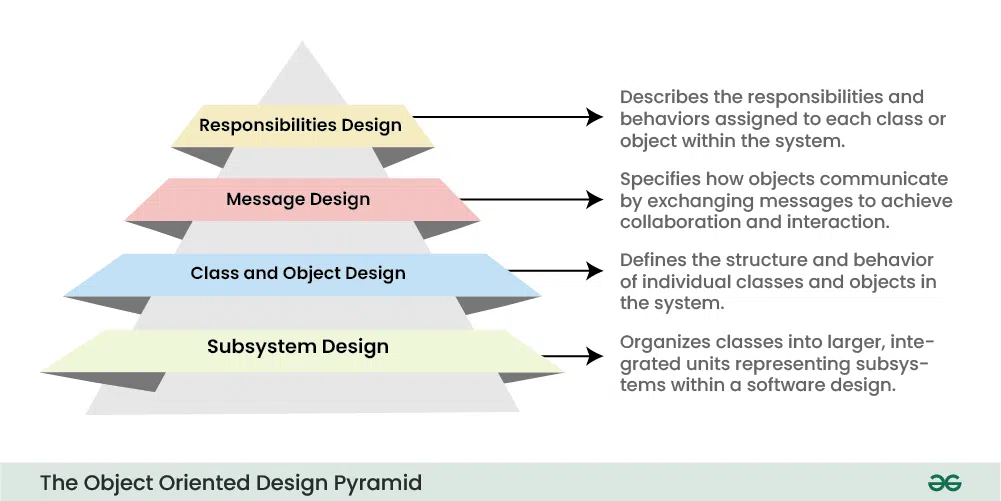


## Beneficios del Análisis y Diseño Orientado a Objetos (ADOO)
- Aumenta la modularidad y la facilidad de mantenimiento del software al fomentar la creación de componentes diminutos y reutilizables que pueden combinarse para crear sistemas más complejos.
- Proporciona una representación abstracta de alto nivel de un sistema de software, lo que facilita su comprensión y mantenimiento.
Promueve los principios del diseño orientado a objetos y la reutilización de objetos, lo que reduce la cantidad de código necesario y mejora la calidad del programa.
- Los ingenieros de software pueden utilizar el mismo lenguaje y método que proporciona OOAD para comunicarse y trabajar en equipo de forma más eficaz.
Puede ayudar a los desarrolladores a crear sistemas de software escalables que se adapten a las cambiantes necesidades de los usuarios y a las demandas del negocio a lo largo del tiempo.
## Desafíos del Análisis y Diseño Orientado a Objetos (ADOO)
- Dado que los objetos y sus interacciones deben explicarse y gestionarse cuidadosamente, esto puede complicar un sistema de software.
- Dado que los objetos deben instanciarse, gestionarse e interactuar con ellos, esto puede generar una sobrecarga adicional y reducir la velocidad del software. Para los ingenieros de software principiantes, el desarrollo orientado a objetos (ADOO) puede presentar una curva de aprendizaje compleja, ya que requiere un sólido conocimiento de los principios y métodos de la POO.
- Puede ser un proceso largo que implica una planificación y documentación previas considerables. Esto puede resultar en tiempos de desarrollo más largos y costos más elevados.
- El ADOO puede ser más costoso que otras metodologías de ingeniería de software debido a la planificación y documentación previas que requiere.


# Elementos del Modelo de Objetos
Este modelo consta de cuatro elementos principales:
1. Abstracción
2. Encapsulación
3. Modularidad
4. Jerarquía

## Abstraccion
Una abstracción denota las características esenciales de un objeto que lo distinguen de todos los demás tipos de objetos y, por lo tanto, proporcionan límites conceptuales claramente definidos, en relación con la perspectiva del espectador.
Una abstracción se centra en la visión externa de un objeto y, por lo tanto, sirve para separar el comportamiento esencial de un objeto de su implementación. La abstracción captura el comportamiento completo de un objeto, ni más ni menos, y no ofrece sorpresas ni efectos secundarios que vayan más allá del alcance de la abstracción.

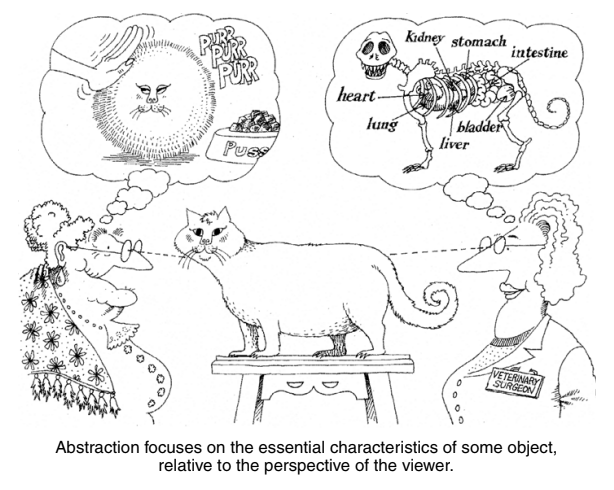


## Encapsulamiento
En pocas palabras, la abstracción de un objeto debe preceder a las decisiones sobre su implementación. Una vez seleccionada una implementación, debe tratarse como un secreto de la abstracción y permanecer oculta para la mayoría de los clientes.
La abstracción y el encapsulamiento son conceptos complementarios: la abstracción se centra en el comportamiento observable de un objeto, mientras que el encapsulamiento se centra en la implementación que da lugar a dicho comportamiento. El encapsulamiento se logra con mayor frecuencia mediante la ocultación de información (no solo de datos), que es el proceso de ocultar todos los secretos de un objeto que no contribuyen a sus características esenciales; normalmente, se oculta la estructura de un objeto, así como la implementación de sus métodos. «Ninguna parte de un sistema complejo debería depender de los detalles internos de ninguna otra parte» [50]. Mientras que la abstracción «ayuda a las personas a pensar en lo que están haciendo», el encapsulamiento «permite realizar cambios en el programa de forma fiable con un esfuerzo limitado» [51].

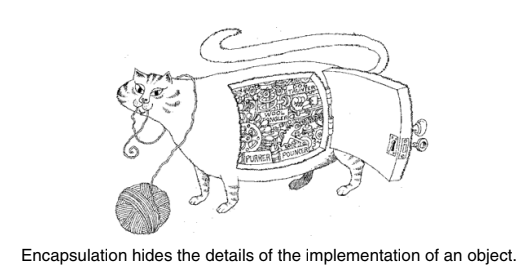

## Modularidad
El desarrollador debe equilibrar dos preocupaciones técnicas contrapuestas: el deseo de encapsular abstracciones y la necesidad de que ciertas abstracciones sean visibles para otros módulos. “Los detalles del sistema que probablemente cambien de forma independiente deben ser secretos de módulos separados; las únicas suposiciones que deben aparecer entre módulos son aquellas que se considera improbable que cambien. Cada estructura de datos es privada para un módulo; uno o más programas dentro del módulo pueden acceder a ella directamente, pero no programas externos. Cualquier otro programa que requiera información almacenada en las estructuras de datos de un módulo debe obtenerla llamando a los programas del módulo” [62]. En otras palabras, esfuércese por construir módulos cohesivos (agrupando abstracciones lógicamente relacionadas) y débilmente acoplados (minimizando las dependencias entre módulos). Desde esta perspectiva, podemos definir la modularidad de la siguiente manera:

La modularidad es la propiedad de un sistema que se ha descompuesto en un conjunto de módulos cohesivos y débilmente acoplados. Por lo tanto, los principios de abstracción, encapsulación y modularidad son sinérgicos.

Un objeto proporciona un límite preciso alrededor de una única abstracción, y tanto la encapsulación como la modularidad proporcionan barreras alrededor de esta abstracción.

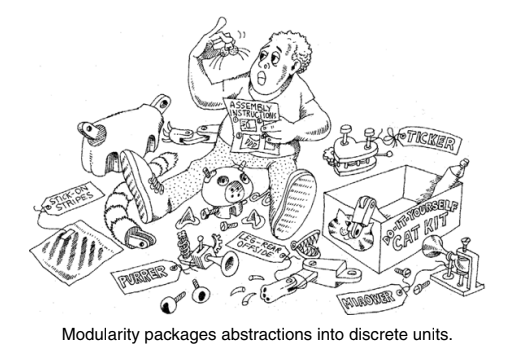

## Jerarquia
La abstracción es buena, pero en todas las aplicaciones, excepto en las más triviales, podemos encontrar muchas más abstracciones diferentes de las que podemos comprender simultáneamente.
El encapsulamiento ayuda a gestionar esta complejidad al ocultar la visión interna de nuestras abstracciones. La modularidad también ayuda, al brindarnos una forma de agrupar abstracciones lógicamente relacionadas. Sin embargo, esto no es suficiente. Un conjunto de abstracciones a menudo forma una jerarquía, y al identificar estas jerarquías en nuestro diseño, simplificamos enormemente nuestra comprensión del problema.
Definimos la jerarquía de la siguiente manera:
La jerarquía es una clasificación u ordenación de abstracciones.
Las dos jerarquías más importantes en un sistema complejo son su estructura de clases (la jerarquía "es un" o herencia) y su estructura de objetos (la jerarquía "tiene un" o composicion).

# Guía de Supervivencia: POO en Python
En Python, "todo es un objeto", pero para programar como un profesional (y aprobar la materia), debes seguir estas reglas:

1. El Constructor y los Atributos (__init__)
El método __init__ no es "donde se crea el objeto", sino donde se inicializa.

Regla de oro: Todos los atributos de la clase deben declararse dentro del __init__. No crees atributos "al vuelo" en otros métodos.

```python
class Estudiante:
    def __init__(self, nombre: str, promedio: float):
        self.nombre = nombre        # Atributo público
        self._promedio = promedio    # Atributo "protegido" (convención)
        self.__id = 12345            # Atributo "privado" (name mangling)
```
2. Encapsulamiento con @property
En Python no usamos getPromedio() o setPromedio(). Usamos decoradores para que el acceso parezca un atributo pero se comporte como un método.

```python
class CuentaBancaria:
    def __init__(self, saldo_inicial: float):
        self._saldo = saldo_inicial

    @property
    def saldo(self):
        """Getter: Permite leer el saldo pero no modificarlo directamente."""
        return self._saldo

    @saldo.setter
    def saldo(self, valor: float):
        """Setter: Aquí puedes validar los datos antes de asignar."""
        if valor < 0:
            raise ValueError("El saldo no puede ser negativo")
        self._saldo = valor
```
3. Abstracción (Contratos)
Para obligar a que las subclases implementen métodos específicos, usamos la librería abc. Esto es lo más parecido a una Interface de Java o C#.

```python
from abc import ABC, abstractmethod

class Animal(ABC):
    @abstractmethod
    def hacer_sonido(self):
        """Este método DEBE ser implementado por las subclases."""
        pass

class Perro(Animal):
    def hacer_sonido(self):
        return "¡Guau!"
```
4. Métodos Especiales (Dunder Methods)
Para que tus clases sean "inteligentes", usa métodos que empiezan y terminan con doble guion bajo (__).

`__str__(self):` Lo que se ve al hacer print(objeto).

`__repr__(self):` Representación técnica (útil para debugging).

`__eq__(self, otro):` Para comparar si dos objetos son "iguales" (obj1 == obj2).

5. El "Checklist" de Calidad Académica
Type Hinting: Indica siempre el tipo de dato. Ayuda a leer el código y evita errores.

Bien: `def suma(a: int, b: int) -> int:`

Mal: `def suma(a, b):`

Docstrings: Usa siempre comillas triples """ """ al inicio de cada clase y método para explicar qué hace.

Self: Nunca olvides que el primer parámetro de cualquier método de instancia debe ser self.

Composición sobre Herencia: Si un objeto "tiene" a otro (ej. un Coche tiene un Motor), no uses herencia. Crea una instancia del motor dentro del coche.

# Principios y Buenas Prácticas de POO en Python

Este documento resume los criterios técnicos y de diseño que se evalúan en los exámenes de Programación Orientada a Objetos. El enfoque principal es la **calidad del código**, la **responsabilidad de las clases** y el uso de **herramientas nativas de Python**.

---

## 1. Validación e Integridad de Datos

Un objeto debe ser el guardián de su propio estado. No se deben aceptar datos que rompan la lógica del negocio.

* **Tipos y Formatos:** Si un atributo debe ser un número de longitud fija (ej. un código identificador) o un texto sin caracteres especiales, la validación debe ocurrir antes de la asignación.
* **Unicidad:** Antes de incorporar un objeto a una colección, se debe verificar que su identificador único no exista ya en el sistema.
* **Consistencia:** Las validaciones deben ser robustas (ej. no aceptar strings vacíos o valores fuera de rangos lógicos).

## 2. El Estado Inicial de los Objetos (`__init__`)

* **Colecciones:** Si un objeto gestiona un conjunto de elementos, estos deben inicializarse como contenedores vacíos (listas `[]` o diccionarios `{}`) dentro del constructor. No se deben pasar como parámetros si el objeto es quien debe administrarlos desde cero.
* **Flags de Control:** Utiliza atributos booleanos para representar el estado de un proceso (ej. `self.activo = True`, `self.procesado = False`). Estos actúan como "llaves de seguridad" para el resto de los métodos.

## 3. Encapsulamiento y Responsabilidad (La Regla de Oro)

Este es el pilar más importante del examen. Se trata de **quién hace qué**.

* **No "metas mano" en otros objetos:** Si el Objeto A tiene una lista, el Objeto B **nunca** debe hacer `objetoA.lista.append()`. El Objeto A debe proveer un método (ej. `agregar_item()`) para que el Objeto B lo llame.
* **Delegación:** Cada clase debe resolver sus propios cálculos. Si un objeto "Hijo" tiene datos para un cálculo, el objeto "Padre" no debe pedirle los datos y calcularlos él; debe llamar a un método del "Hijo" que devuelva el resultado.

## 4. El "Pythonic Way": Funciones Nativas

Python está diseñado para ser eficiente. El uso de bucles manuales (`for`) para tareas que ya tienen funciones integradas penaliza en el examen:

* **Sumatorias:** Utiliza `sum()` en lugar de acumuladores manuales.
* **Ordenamiento:** Utiliza `sorted()` o el método `.sort()`. Nunca programes un algoritmo de ordenamiento manual a menos que se pida.
* **Filtrado:** Utiliza la función `filter()` o *List Comprehensions* para obtener subconjuntos de datos.
* **Reutilización:** Si un objeto ya sabe cómo imprimirse (`__str__`), cuando quieras mostrar una lista de esos objetos, llama a ese método. No vuelvas a concatenar los atributos manualmente.

## 5. Gestión de Procesos y Lógica de Flujo

Los métodos que ejecutan acciones críticas (como cerrar un proceso o generar un reporte) deben seguir este orden lógico:

1. **Validación de estado:** ¿El proceso ya terminó? ¿El objeto existe?
2. **Ejecución:** Realizar la tarea (cálculos, sorteos, etc.).
3. **Actualización de estado:** Cambiar el valor de los *flags* (ej. marcar como "Finalizado").

## 6. Persistencia y Reportes (Archivos)

Al trabajar con archivos (como CSV o TXT), asegúrate de:

* **Verificar condiciones de éxito:** No generar archivos si el proceso previo no ha terminado correctamente según las banderas de control.
* **Formato estricto:** Respetar los nombres de archivo y el formato de columnas solicitado.
* **Filtrado previo:** Seleccionar solo los datos que cumplen con el criterio solicitado antes de iniciar la escritura.

---

### 🚨 Errores comunes que restan puntos:

* **Romper el encapsulamiento:** Acceder a atributos con guiones bajos o modificar listas internas de otra clase desde afuera.
* **Código redundante:** Copiar y pegar la misma lógica en tres lugares distintos en lugar de usar herencia o un método común.
* **Ignorar funciones de Python:** Usar un `for` para buscar un valor que podría encontrarse con un método de lista o una función nativa.
* **Falta de validación:** Confiar en que el usuario siempre ingresará datos correctos.


# Excepciones <a name="excepciones"></a>

Las excepciones son el mecanismo que usa Python para manejar situaciones anómalas durante la ejecución. En el paradigma orientado a objetos, las excepciones son **objetos**: instancias de clases que forman una jerarquía de herencia.

Lejos de ser un recurso de "último momento", el manejo de excepciones es parte integral del **diseño**. Bertrand Meyer lo formalizó en el concepto de *Design by Contract*: cada método tiene precondiciones (qué espera recibir) y postcondiciones (qué garantiza producir). Las excepciones son el instrumento para comunicar que ese contrato fue violado.

> **En la práctica:** en proyectos reales, las excepciones mal diseñadas son una fuente constante de bugs difíciles de rastrear. Una excepción genérica como `Exception("algo salió mal")` no le dice nada a quien la captura. Una excepción bien diseñada como `StockInsuficienteError` es autodocumentada y le permite a quien llama tomar decisiones informadas.

## Excepciones Built-in Principales

Python incluye una jerarquía de excepciones. Todas heredan de `BaseException`, pero en código de aplicación trabajás casi siempre con subclases de `Exception`:

```
BaseException
 ├── SystemExit           → sys.exit() lo lanza, no lo capturés
 ├── KeyboardInterrupt    → Ctrl+C, tampoco lo capturés
 └── Exception
      ├── ValueError       → tipo correcto, valor inválido (ej: precio negativo)
      ├── TypeError        → tipo incorrecto (ej: recibís str, esperabas int)
      ├── AttributeError   → el atributo no existe en el objeto
      ├── KeyError         → la clave no existe en el diccionario
      ├── IndexError       → índice fuera de rango en una lista
      ├── FileNotFoundError → el archivo no existe
      ├── NotImplementedError → método abstracto sin implementar
      └── RuntimeError     → error genérico en tiempo de ejecución
```

| Excepción | Cuándo usarla |
|---|---|
| `ValueError` | El argumento tiene el tipo correcto pero un valor semánticamente inválido |
| `TypeError` | El argumento tiene el tipo incorrecto |
| `AttributeError` | Se accede a un atributo que no existe en el objeto |
| `KeyError` | Se busca una clave inexistente en un `dict` |
| `IndexError` | Se accede a un índice fuera de rango en una lista |
| `NotImplementedError` | Método que las subclases deben implementar (alternativa a ABC) |

### Estructura del manejo de excepciones

```python
try:
    # código que puede fallar
except TipoDeError as e:
    # qué hacer si ocurre ese error específico
except OtroTipoDeError as e:
    # qué hacer si ocurre este otro error
else:
    # se ejecuta solo si NO hubo ninguna excepción en el try
finally:
    # se ejecuta siempre, con o sin excepción (ideal para liberar recursos)
```

El bloque `else` es útil para separar "la operación exitosa" del bloque `try`, dejando este último solo para el manejo de errores. El bloque `finally` es ideal para cerrar archivos, conexiones a bases de datos, etc.

In [ ]:
# ── Uso de excepciones built-in en una clase de dominio ──────────────────

class CuentaBancaria:
    """
    Cuenta bancaria con saldo protegido.

    Attributes:
        titular: Nombre del titular de la cuenta.
    """

    def __init__(self, titular: str, saldo_inicial: float = 0.0) -> None:
        if not isinstance(titular, str) or not titular.strip():
            raise TypeError("El titular debe ser un string no vacío")
        if saldo_inicial < 0:
            raise ValueError(f"El saldo inicial no puede ser negativo: {saldo_inicial}")
        self._titular = titular
        self._saldo = saldo_inicial

    @property
    def saldo(self) -> float:
        return self._saldo

    @property
    def titular(self) -> str:
        return self._titular

    def depositar(self, monto: float) -> None:
        """Incrementa el saldo. Lanza ValueError si el monto no es positivo."""
        if monto <= 0:
            raise ValueError(f"El monto a depositar debe ser positivo, recibí: {monto}")
        self._saldo += monto

    def retirar(self, monto: float) -> None:
        """Decrementa el saldo. Lanza ValueError si el monto es inválido o el saldo insuficiente."""
        if monto <= 0:
            raise ValueError(f"El monto a retirar debe ser positivo, recibí: {monto}")
        if monto > self._saldo:
            raise ValueError(
                f"Saldo insuficiente: tenés ${self._saldo:.2f}, intentás retirar ${monto:.2f}"
            )
        self._saldo -= monto

    def __repr__(self) -> str:
        return f"CuentaBancaria({self._titular!r}, saldo=${self._saldo:.2f})"


# ── Patrones de manejo ────────────────────────────────────────────────────

cuenta = CuentaBancaria("Ana García", 1000.0)

# try / except / else / finally
try:
    cuenta.retirar(200.0)
    saldo_actual = cuenta.saldo      # solo se ejecuta si no hubo excepción
except ValueError as e:
    print(f"Error de negocio: {e}")
else:
    print(f"Retiro exitoso. Saldo actual: ${saldo_actual:.2f}")   # ✅ se ejecuta
finally:
    print("Operación registrada.")                                 # siempre se ejecuta

print()

# Capturar múltiples excepciones en orden de especificidad
try:
    cuenta_invalida = CuentaBancaria(123, -500)   # TypeError
except TypeError as e:
    print(f"Tipo inválido: {e}")
except ValueError as e:
    print(f"Valor inválido: {e}")

print()

# Relanzar una excepción después de loguearla
try:
    cuenta.retirar(9999.0)
except ValueError as e:
    print(f"[LOG] Intento de retiro rechazado: {e}")
    raise   # re-lanza la misma excepción hacia arriba en el stack

## Excepciones Personalizadas

Las excepciones built-in son suficientes para errores de programación: un `TypeError` o `ValueError` son claros. Pero para **reglas de negocio** propias de tu dominio, lo correcto es definir excepciones propias.

### ¿Por qué crear excepciones propias?

- **Semántica**: `StockInsuficienteError` comunica el problema sin necesidad de leer el mensaje.
- **Captura selectiva**: quien llama puede hacer `except StockInsuficienteError` para manejar ese caso específico sin capturar otros errores.
- **Información adicional**: podés agregar atributos con el contexto relevante (qué producto, cuánto había, cuánto se pidió).

### Patrón recomendado

Definí una excepción base por módulo o dominio, y excepciones específicas que hereden de ella. Esto le permite a quien llama capturar errores genéricos del dominio (`except InventarioError`) o específicos (`except StockInsuficienteError`):

```
Exception
 └── InventarioError                ← excepción base del dominio
      ├── StockInsuficienteError    ← error específico con atributos propios
      └── ProductoNoEncontradoError ← otro error específico
```

In [ ]:
# ── Jerarquía de excepciones de dominio ──────────────────────────────────

class InventarioError(Exception):
    """Excepción base para todos los errores del módulo de inventario."""
    pass


class StockInsuficienteError(InventarioError):
    """Se lanza cuando no hay suficiente stock para completar una operación."""

    def __init__(self, producto: str, disponible: int, solicitado: int) -> None:
        self.producto = producto
        self.disponible = disponible
        self.solicitado = solicitado
        super().__init__(
            f"Stock insuficiente para '{producto}': "
            f"disponible={disponible}, solicitado={solicitado}"
        )


class ProductoNoEncontradoError(InventarioError):
    """Se lanza cuando se busca un producto que no existe en el inventario."""

    def __init__(self, nombre: str) -> None:
        self.nombre = nombre
        super().__init__(f"Producto no encontrado: '{nombre}'")


# ── Clase que usa las excepciones de dominio ─────────────────────────────

class Producto:
    """
    Representa un producto con nombre, precio y stock disponible.

    Args:
        nombre: Nombre del producto.
        precio: Precio unitario (debe ser positivo).
        stock: Cantidad disponible (debe ser no negativa).
    """

    def __init__(self, nombre: str, precio: float, stock: int) -> None:
        self.nombre = nombre
        self._precio = precio
        self._stock = stock

    def vender(self, cantidad: int) -> float:
        """
        Descuenta stock y retorna el total de la venta.

        Raises:
            ValueError: si la cantidad no es positiva.
            StockInsuficienteError: si no hay suficiente stock.
        """
        if cantidad <= 0:
            raise ValueError("La cantidad debe ser positiva")
        if cantidad > self._stock:
            raise StockInsuficienteError(self.nombre, self._stock, cantidad)
        self._stock -= cantidad
        return cantidad * self._precio


# ── Uso con captura selectiva ─────────────────────────────────────────────

laptop = Producto("Laptop", 1500.0, 3)

try:
    total = laptop.vender(10)
except StockInsuficienteError as e:
    # Accedemos a los atributos del error para tomar decisiones informadas
    print(f"No podemos completar el pedido: {e}")
    print(f"Te ofrecemos {e.disponible} unidades en su lugar.")
except InventarioError as e:
    # Captura cualquier otro error del dominio
    print(f"Error de inventario: {e}")

print()

try:
    total = laptop.vender(2)
    print(f"Venta exitosa: ${total:.2f}")
except StockInsuficienteError as e:
    print(f"Error: {e}")

# Testing de Clases con pytest <a name="testing"></a>

Un programa sin tests es un programa que no sabés si funciona. En POO, los tests tienen un rol especial: **verifican el contrato público de una clase**. Si cambiás la implementación interna sin romper los tests, sabés que el comportamiento externo se preservó.

## ¿Qué es un test unitario?

Un **test unitario** testea **una sola unidad** de código en aislamiento. En POO, la unidad es una clase. El objetivo es verificar que sus métodos se comportan correctamente dado un estado inicial y unos inputs determinados.

Lo que **no** hace un test unitario:
- No testea cómo dos clases interactúan entre sí (eso es un test de integración).
- No testea la base de datos, la red ni el sistema de archivos.
- No testea lógica de otras clases relacionadas.

Si tu clase `Inventario` usa una clase `Producto`, en el test de `Inventario` vas a **simular** el comportamiento de `Producto` con un *mock*, sin usar la clase real. Así, si `Producto` tiene un bug, los tests de `Inventario` no fallan por eso.

## pytest: El Framework Estándar

`pytest` es el framework de testing más usado en el ecosistema Python. Es más conciso que `unittest` y tiene un sistema de descubrimiento automático de tests.

### Instalación

```bash
pip install pytest pytest-mock
```

### Estructura de archivos

```
mi_proyecto/
├── src/
│   ├── cuenta_bancaria.py
│   └── producto.py
└── tests/
    ├── test_cuenta_bancaria.py
    └── test_producto.py
```

- Los archivos de test deben llamarse `test_*.py` o `*_test.py`.
- Las funciones (o métodos de clase) de test deben llamarse `test_*`.
- pytest los descubre y ejecuta automáticamente.

### Cómo correr los tests

```bash
# Correr todos los tests del proyecto
pytest

# Correr un archivo específico
pytest tests/test_cuenta_bancaria.py

# Correr un test específico por nombre
pytest tests/test_cuenta_bancaria.py::TestCuentaBancaria::test_depositar_incrementa_el_saldo

# Ver output detallado (nombre de cada test + resultado)
pytest -v

# Mostrar solo los tests que fallan, con traceback corto
pytest -v --tb=short
```

### Assertions en pytest

pytest usa el `assert` nativo de Python. Cuando una aserción falla, pytest muestra exactamente qué valores tenía cada lado, lo que hace que los mensajes de error sean muy informativos:

```python
assert cuenta.saldo == 1500    # si falla: AssertionError: assert 1200 == 1500
assert resultado is not None
assert "error" in mensaje.lower()
```

In [ ]:
# ── Clase bajo test ──────────────────────────────────────────────────────
# En un proyecto real esto estaría en src/cuenta_bancaria.py y se importaría.
# Lo incluimos aquí para que la celda sea autosuficiente.

class CuentaBancaria:
    """Cuenta bancaria con saldo controlado."""

    def __init__(self, titular: str, saldo_inicial: float = 0.0) -> None:
        if saldo_inicial < 0:
            raise ValueError("El saldo inicial no puede ser negativo")
        self._titular = titular
        self._saldo = saldo_inicial

    @property
    def saldo(self) -> float:
        return self._saldo

    @property
    def titular(self) -> str:
        return self._titular

    def depositar(self, monto: float) -> None:
        if monto <= 0:
            raise ValueError("El monto debe ser positivo")
        self._saldo += monto

    def retirar(self, monto: float) -> None:
        if monto <= 0:
            raise ValueError("El monto debe ser positivo")
        if monto > self._saldo:
            raise ValueError("Saldo insuficiente")
        self._saldo -= monto


# ── archivo: tests/test_cuenta_bancaria.py ───────────────────────────────
# Para correr: pytest tests/test_cuenta_bancaria.py -v

import pytest


class TestCuentaBancaria:
    """Tests unitarios para CuentaBancaria."""

    # ── Tests del constructor ─────────────────────────────────────────────

    def test_saldo_inicial_por_defecto_es_cero(self) -> None:
        cuenta = CuentaBancaria("Carlos")
        assert cuenta.saldo == 0.0

    def test_saldo_inicial_se_asigna_correctamente(self) -> None:
        cuenta = CuentaBancaria("Carlos", 1000.0)
        assert cuenta.saldo == 1000.0

    def test_titular_se_asigna_correctamente(self) -> None:
        cuenta = CuentaBancaria("Ana García")
        assert cuenta.titular == "Ana García"

    def test_saldo_inicial_negativo_lanza_value_error(self) -> None:
        with pytest.raises(ValueError):
            CuentaBancaria("Carlos", -100.0)

    # ── Tests de depositar ────────────────────────────────────────────────

    def test_depositar_incrementa_el_saldo(self) -> None:
        cuenta = CuentaBancaria("Carlos", 1000.0)
        cuenta.depositar(500.0)
        assert cuenta.saldo == 1500.0

    def test_depositar_monto_negativo_lanza_value_error(self) -> None:
        cuenta = CuentaBancaria("Carlos", 1000.0)
        with pytest.raises(ValueError, match="debe ser positivo"):
            cuenta.depositar(-50.0)

    def test_depositar_cero_lanza_value_error(self) -> None:
        cuenta = CuentaBancaria("Carlos")
        with pytest.raises(ValueError):
            cuenta.depositar(0)

    # ── Tests de retirar ──────────────────────────────────────────────────

    def test_retirar_reduce_el_saldo(self) -> None:
        cuenta = CuentaBancaria("Carlos", 1000.0)
        cuenta.retirar(300.0)
        assert cuenta.saldo == 700.0

    def test_retirar_exactamente_el_saldo_disponible(self) -> None:
        """Caso borde: retirar exactamente lo que hay disponible."""
        cuenta = CuentaBancaria("Carlos", 500.0)
        cuenta.retirar(500.0)
        assert cuenta.saldo == 0.0

    def test_retirar_mas_del_saldo_lanza_value_error(self) -> None:
        cuenta = CuentaBancaria("Carlos", 100.0)
        with pytest.raises(ValueError, match="Saldo insuficiente"):
            cuenta.retirar(200.0)


# ── Fixtures: setup compartido entre tests ────────────────────────────────
# Una fixture es una función decorada con @pytest.fixture que provee
# un objeto preconfigurado. Reemplaza el setUp() de unittest.

@pytest.fixture
def cuenta_con_saldo() -> CuentaBancaria:
    """Cuenta con saldo de $1000 lista para usar en los tests."""
    return CuentaBancaria("Test User", 1000.0)


class TestCuentaBancariaConFixture:
    """Mismos tests usando fixtures para no repetir el setup en cada uno."""

    def test_depositar_con_fixture(self, cuenta_con_saldo: CuentaBancaria) -> None:
        cuenta_con_saldo.depositar(200.0)
        assert cuenta_con_saldo.saldo == 1200.0

    def test_retirar_con_fixture(self, cuenta_con_saldo: CuentaBancaria) -> None:
        cuenta_con_saldo.retirar(400.0)
        assert cuenta_con_saldo.saldo == 600.0


# ── Para ejecutar desde la terminal ──────────────────────────────────────
# Guardá las clases en src/cuenta_bancaria.py y los tests en tests/test_cuenta_bancaria.py
# Luego corré:
#   pytest tests/test_cuenta_bancaria.py -v

## Mocking: Aislar la Clase Bajo Test

Cuando una clase depende de otra, no querés que los tests de la primera fallen por culpa de la segunda. La solución es **mockear** la dependencia: reemplazarla con un objeto simulado que se comporta exactamente como vos necesitás para el test.

### ¿Cuándo mockear?

- Cuando tu clase usa otra clase de dominio (para aislar la unidad bajo test).
- Cuando la dependencia conecta con recursos externos: bases de datos, APIs, sistema de archivos.
- Cuando necesitás simular condiciones difíciles de reproducir (ej: una API que devuelve error 500).

### Herramientas

Python incluye `unittest.mock` en la biblioteca estándar. Con `pytest-mock` obtenés la fixture `mocker` que simplifica la sintaxis:

```bash
pip install pytest-mock
```

### Qué hacen los mocks

| Necesidad | Herramienta |
|---|---|
| Reemplazar una clase entera con un objeto falso | `MagicMock(spec=MiClase)` |
| Controlar qué retorna un método | `mock.metodo.return_value = valor` |
| Simular que un método lanza una excepción | `mock.metodo.side_effect = MiError(...)` |
| Verificar que un método fue llamado | `mock.metodo.assert_called_once_with(args)` |
| Verificar que un método NO fue llamado | `mock.metodo.assert_not_called()` |

> **Nota sobre `spec=`**: usar `MagicMock(spec=MiClase)` hace que el mock solo permita llamar a los métodos que `MiClase` realmente tiene. Si llamás a un método inexistente, el test falla. Esto evita que los mocks "aprueben" código que llama a métodos con nombres incorrectos.

In [ ]:
# ── Clases del dominio ────────────────────────────────────────────────────
# En un proyecto real estas estarían en archivos separados.

class GatewayPago:
    """Servicio externo de pago (ej: Mercado Pago, Stripe)."""

    def procesar(self, monto: float, tarjeta: str) -> bool:
        """Llama a la API externa. En tests NO queremos que esto suceda."""
        raise NotImplementedError("Esto conectaría con la API real")


class ProcesadorPedido:
    """
    Procesa un pedido usando un gateway de pago externo.

    Attributes:
        gateway: Servicio de pago inyectado por el constructor.
        comision: Porcentaje de comisión sobre el total (0.0 a 1.0).
    """

    def __init__(self, gateway: GatewayPago, comision: float = 0.05) -> None:
        self._gateway = gateway
        self._comision = comision

    def procesar_pedido(self, monto: float, tarjeta: str) -> dict:
        """
        Procesa el pago de un pedido.

        Returns:
            dict con 'aprobado' (bool) y 'total_cobrado' (float).

        Raises:
            ValueError: si el monto no es positivo.
        """
        if monto <= 0:
            raise ValueError(f"El monto debe ser positivo: {monto}")
        total = monto * (1 + self._comision)
        aprobado = self._gateway.procesar(total, tarjeta)
        return {"aprobado": aprobado, "total_cobrado": total if aprobado else 0.0}


# ── archivo: tests/test_procesador_pedido.py ─────────────────────────────
# Para correr: pytest tests/test_procesador_pedido.py -v

import pytest
from unittest.mock import MagicMock


class TestProcesadorPedido:
    """
    Tests unitarios de ProcesadorPedido.
    GatewayPago es mockeado: nunca se llama a la API real.
    """

    def test_pedido_aprobado_retorna_total_con_comision(self) -> None:
        # Arrange: creamos un mock de GatewayPago
        gateway_mock = MagicMock(spec=GatewayPago)
        gateway_mock.procesar.return_value = True   # simulamos que el pago se aprueba

        procesador = ProcesadorPedido(gateway_mock, comision=0.10)

        # Act
        resultado = procesador.procesar_pedido(100.0, "4111-1111-1111-1111")

        # Assert
        assert resultado["aprobado"] is True
        assert resultado["total_cobrado"] == pytest.approx(110.0)   # 100 + 10% comisión

    def test_pedido_rechazado_retorna_cero(self) -> None:
        gateway_mock = MagicMock(spec=GatewayPago)
        gateway_mock.procesar.return_value = False   # simulamos rechazo

        procesador = ProcesadorPedido(gateway_mock)
        resultado = procesador.procesar_pedido(200.0, "tarjeta-invalida")

        assert resultado["aprobado"] is False
        assert resultado["total_cobrado"] == 0.0

    def test_gateway_es_llamado_con_el_monto_correcto(self) -> None:
        """Verifica que el procesador llama al gateway con monto + comisión."""
        gateway_mock = MagicMock(spec=GatewayPago)
        gateway_mock.procesar.return_value = True

        procesador = ProcesadorPedido(gateway_mock, comision=0.05)
        procesador.procesar_pedido(100.0, "mi-tarjeta")

        # Verificamos que el gateway fue llamado exactamente una vez y con los args correctos
        gateway_mock.procesar.assert_called_once_with(pytest.approx(105.0), "mi-tarjeta")

    def test_monto_negativo_lanza_error_sin_llamar_al_gateway(self) -> None:
        gateway_mock = MagicMock(spec=GatewayPago)
        procesador = ProcesadorPedido(gateway_mock)

        with pytest.raises(ValueError):
            procesador.procesar_pedido(-50.0, "tarjeta")

        # El gateway nunca debe ser llamado si el monto es inválido
        gateway_mock.procesar.assert_not_called()

    def test_gateway_que_falla_propaga_la_excepcion(self) -> None:
        """Simula que la API externa no está disponible."""
        gateway_mock = MagicMock(spec=GatewayPago)
        gateway_mock.procesar.side_effect = ConnectionError("API no disponible")

        procesador = ProcesadorPedido(gateway_mock)

        with pytest.raises(ConnectionError, match="API no disponible"):
            procesador.procesar_pedido(100.0, "tarjeta")

# Fuentes
- Object Oriented Analysis and Design with Applications 3rd Edition by Booch
- Codigo Limpio - Robert C. Martin
- https://profile.es/blog/que-son-los-paradigmas-de-programacion/
- https://es.wikipedia.org/wiki/Programaci%C3%B3n_estructurada
- https://www.disrupciontecnologica.com/acoplamiento-y-cohesion/
- https://refactoring.guru/refactoring/what-is-refactoring
- https://www.geeksforgeeks.org/software-engineering/object-oriented-analysis-and-design/